In [11]:
# TASK 1 : DATA CLEANING & PREPROCESSING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# STEP 1 : LOAD DATASET

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Shape of dataset
print("\nShape of Dataset:")
print(df.shape)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [12]:
# STEP 2 : CHECK MISSING VALUES

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [13]:
# STEP 3 : HANDLE MISSING VALUES

# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column because too many missing values
df.drop(columns=['Cabin'], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [14]:
# STEP 4 : ENCODE CATEGORICAL VARIABLES

# Label Encoding
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df['Embarked'] = le.fit_transform(df['Embarked'])

print("\nDataset After Encoding:")
print(df.head())


Dataset After Encoding:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  Embarked  
0         A/5 21171   7.2500         2  
1          PC 17599  71.2833         0  
2  STON/O2. 3101282   7.9250         2  
3            113803  53.1000         2  
4            373450   8.0500         2  


In [15]:
# STEP 5 : FEATURE SCALING

# Select numerical columns
numerical_columns = ['Age', 'Fare']

# Standardization
scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print("\nDataset After Scaling:")
print(df.head())


Dataset After Scaling:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    1 -0.565736      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  0.663861      1   
2                             Heikkinen, Miss. Laina    0 -0.258337      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.433312      1   
4                           Allen, Mr. William Henry    1  0.433312      0   

   Parch            Ticket      Fare  Embarked  
0      0         A/5 21171 -0.502445         2  
1      0          PC 17599  0.786845         0  
2      0  STON/O2. 3101282 -0.488854         2  
3      0            113803  0.420730         2  
4      0            373450 -0.486337         

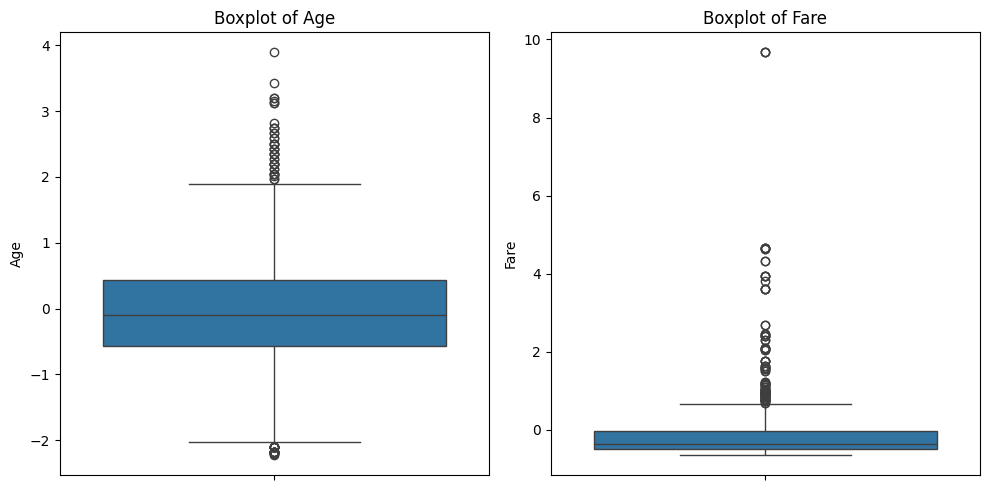

In [16]:
# STEP 6 : OUTLIER DETECTION

# Boxplot before removing outliers
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['Age'])
plt.title("Boxplot of Age")

plt.subplot(1,2,2)
sns.boxplot(y=df['Fare'])
plt.title("Boxplot of Fare")

plt.tight_layout()
plt.show()

In [17]:
# STEP 7 : REMOVE OUTLIERS USING IQR METHOD

# Function to remove outliers
def remove_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[
        (data[column] >= lower_bound) &
        (data[column] <= upper_bound)
    ]

# Remove outliers from Age and Fare
df = remove_outliers(df, 'Age')
df = remove_outliers(df, 'Fare')

print("\nShape After Removing Outliers:")
print(df.shape)




Shape After Removing Outliers:
(718, 11)


In [18]:
# STEP 8 : FINAL DATASET INFO


print("\nFinal Cleaned Dataset:")
print(df.head())

print("\nFinal Dataset Info:")
print(df.info())




Final Cleaned Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name  Sex       Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    1 -0.565736      1      0   
2                        Heikkinen, Miss. Laina    0 -0.258337      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.433312      1      0   
4                      Allen, Mr. William Henry    1  0.433312      0      0   
5                              Moran, Mr. James    1 -0.104637      0      0   

             Ticket      Fare  Embarked  
0         A/5 21171 -0.502445         2  
2  STON/O2. 3101282 -0.488854         2  
3            113803  0.420730         2  
4            373450 -0.486337         2  
5            330877 -0.478116         1  

Final Dataset Info:
<clas

In [19]:

# STEP 9 : SAVE CLEANED DATASET

df.to_csv("Cleaned_Titanic_Dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully!")


Cleaned Dataset Saved Successfully!
